In [1]:
import matplotlib
%matplotlib inline

In [18]:
import numpy as np
import torch
import torch.distributions as td
import matplotlib.pyplot as plt

In [146]:
class MoG():
    def __init__(self, means, covars, weights=None,
                 dtype=torch.float32, device='cpu'):
        """
        Class to handle operations around mixtures of multivariate
        Gaussian distributions
        Args:
            means: list of 1d tensors of centroids
            covars: list of 2d tensors of covariances
            weights: list of relative statistical weights (does not need to sum to 1)
        """
        self.device = device
        self.beta = 1.  # model 'temperature' for sampling with langevin and mh
        self.means = means
        self.covars = covars
        self.dim = means[0].shape[0]
        self.k = len(means)  # number of components in the mixture

        if weights is not None:
            self.weights = torch.tensor(weights, dtype=dtype, device=device)
        else:
            self.weights = torch.tensor([1 / self.k] * self.k,
                                        dtype=dtype, device=device)

        self.cs_distrib = td.categorical.Categorical(probs=self.weights)
        self.normal_distribs = []
        for c in range(self.k):
            c_distrib = td.multivariate_normal.MultivariateNormal(
                self.means[c].to(device),
                covariance_matrix=self.covars[c].to(device)
                )
            self.normal_distribs.append(c_distrib)

        self.covars_inv = torch.stack([torch.inverse(cv) for cv in covars])
        self.dets = torch.stack([torch.det(cv) for cv in covars])

    def sample(self, n):
        cs = self.cs_distrib.sample_n(n).to(self.device)

        samples = torch.zeros((n, self.dim), device=self.device)
        for c in range(self.k):
            n_c = (cs == c).sum()
            samples[cs == c, :] = self.normal_distribs[c].sample_n(n_c)
        return samples.to(self.device)

    def log_prob(self, x):
        x = x.unsqueeze(1)
        m = torch.stack(self.means).unsqueeze(0)
        args = - 0.5 * torch.einsum('kci,cij,kcj->kc', x-m, self.covars_inv, x-m)
        args += torch.log(self.weights)
        args -= torch.log((self.weights.sum() * torch.sqrt((2 * np.pi) ** self.dim * self.dets)))
        return  torch.logsumexp(args, 1)

sep = 2.
means = [torch.tensor([-sep, 0]), torch.tensor([sep, 0])]
covars = [2e-1 * torch.eye(2),  2e-2 * torch.eye(2)]

target = MoG(means, covars)
target_log_prob = target.log_prob

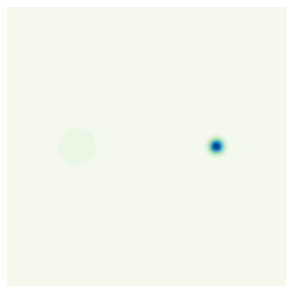

In [147]:
lims = {'x_min':-2 * sep, 'x_max':2 * sep, 'y_min':-2 * sep, 'y_max':2 * sep}
device = 'cpu'

def set_plot(ax, n_points=1000, target_log_prob=target_log_prob, prop_log_prob=None, lims=lims):
    
    x_range = torch.linspace(lims['x_min'], lims['x_max'], n_points, device=device)

    if lims['y_min'] is None:
        y_range = x_range.clone()
    else:
        y_range = torch.linspace(lims['y_min'], lims['y_max'], n_points, device=device)

    grid = torch.meshgrid(x_range, y_range)
    xys = torch.stack(grid).reshape(2, n_points ** 2).T.to(device)

    Us_target = target_log_prob(xys).reshape(n_points, n_points).T.detach().cpu().numpy()

    if ax is None:
        plt.figure()
    else:
        plt.sca(ax)
    plt.axis('off')

    plt.contourf(x_range, y_range, np.exp(Us_target)
    # np.log( - Us_target + Us_target.max() + 1)
    , 20, cmap='GnBu')
    ax.set_aspect('equal')

    if prop_log_prob is not None:
        Us_prop = prop_log_prob(xys).reshape(n_points, n_points).T.detach().cpu().numpy()

        plt.contour(x_range, y_range, - Us_prop, 20, colors='k', linestyles=':', alpha=0.5)


plt.figure(figsize=(5,7))
# plt.suptitle()
ax = plt.subplot(1,1,1)
set_plot(ax)

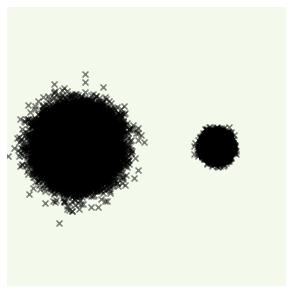

In [180]:
n_data = 100000
data = target.sample(n_data)

plt.figure(figsize=(5,7))
# plt.suptitle()
ax = plt.subplot(1,1,1)
set_plot(ax)
plt.scatter(data[:, 0], data[:, 1], marker='x', color='k', alpha=0.5)

In [181]:
def run_discrete_mcmc(data, x_init, n_steps):

    xs = []
    accs = []

    for t in range(n_steps):
        prop = torch.randint(data.shape[0], size=(x_init.shape[0],))
        x = data[prop]
        log_ratio = target_log_prob(x) - target_log_prob(x_init)
        log_u = torch.log(torch.rand_like(log_ratio))
        acc = log_u < log_ratio
        x[~acc] = x_init[~acc]

        accs.append(acc)
        xs.append(x.clone())
        x_init = x.clone().detach()

    return torch.stack(xs), torch.stack(accs)



In [182]:
x_init = data[:100]
n_steps = 10000

xs, accs = run_discrete_mcmc(data, x_init, n_steps)

In [183]:
print('Mean acceptance', torch.mean(accs * 1.).item())
print('Relative weights of positive mode', torch.mean((xs[:, :, 0] > 0) * 1.).item() )
print('Relative weights in init', torch.mean((data[:, 0] > 0) * 1.).item() )

Mean acceptance 0.4211849868297577
Relative weights of positive mode 0.9089739918708801
Relative weights in init 0.4990699887275696


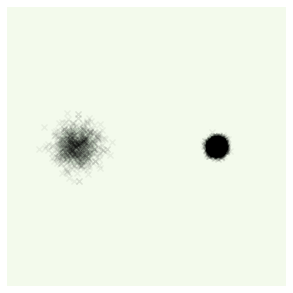

In [184]:
chain_number = 0
plt.figure(figsize=(5,7))
# plt.suptitle()
ax = plt.subplot(1,1,1)
set_plot(ax)
plt.scatter(xs[:, chain_number, 0], xs[:, chain_number, 1], marker='x', color='k',alpha=0.05)

Comparing to proposing with Gaussian mixture:

In [176]:
sep = 2.
means_prop = [torch.tensor([-sep, 0]), torch.tensor([sep, 0])]
covars_prop = [2e-1 * torch.eye(2),  2e-1 * torch.eye(2)]

prop = MoG(means_prop, covars_prop)
prop_log_prob = prop.log_prob


def run_metropolis(x_init, n_steps):

    xs = []
    accs = []

    for t in range(n_steps):
        x = prop.sample(x_init.shape[0])
        log_ratio = target_log_prob(x) - prop_log_prob(x)
        log_ratio += - target_log_prob(x_init) + prop_log_prob(x_init)
        log_ratio =  log_ratio
        log_u = torch.log(torch.rand_like(log_ratio))
        acc = log_u < log_ratio
        x[~acc] = x_init[~acc]

        accs.append(acc)
        xs.append(x.clone())
        x_init = x.clone().detach()

    return torch.stack(xs), torch.stack(accs)

In [177]:
x_init = data[:10]
n_steps = 10000

xs, accs = run_metropolis(x_init, n_steps)

In [178]:
print('Mean acceptance', torch.mean(accs * 1.).item())
print('Relative weights of positive mode', torch.mean((xs[:, :, 0] > 0) * 1.).item() )
print('Relative weights in init', torch.mean((data[:, 0] > 0) * 1.).item() )

Mean acceptance 0.44558000564575195
Relative weights of positive mode 0.4988600015640259
Relative weights in init 0.49665001034736633


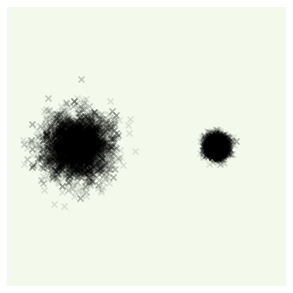

In [179]:
chain_number = 0
plt.figure(figsize=(5,7))
# plt.suptitle()
ax = plt.subplot(1,1,1)
set_plot(ax)
plt.scatter(xs[:, chain_number, 0], xs[:, chain_number, 1], marker='x', color='k',alpha=0.1)